<a href="https://colab.research.google.com/github/Mansik-04/assignments/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Bike Dataset EDA Assignment
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load dataset
# Upload the dataset manually in Colab or use the provided path
from google.colab import files
uploaded = files.upload()

# Replace "bike_data.csv" with the actual uploaded filename
df = pd.read_csv("BIKE DETAILS.csv")

# Step 3: Preview data
print(df.shape)
df.head()

Saving BIKE DETAILS.csv to BIKE DETAILS (1).csv
(1061, 7)


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


In [3]:
#ques 1
df['selling_price'].min(), df['selling_price'].max()


(5000, 760000)

In [4]:
#ques 2
df['selling_price'].median()


45000.0

In [5]:
#ques 3.
df['seller_type'].value_counts().idxmax()


'Individual'

In [6]:
#ques 4
(df['km_driven'] > 50000).sum()


np.int64(170)

In [7]:
#Q5: Average km_driven for each ownership type
df.groupby('owner')['km_driven'].mean()



,km_driven
owner,
1st owner,32816.583333
2nd owner,39288.991870
3rd owner,33292.181818
4th owner,311500.000000


In [8]:
#Q6: Proportion of bikes from year ≤ 2015
(df['year'] <= 2015).mean()

np.float64(0.5664467483506126)

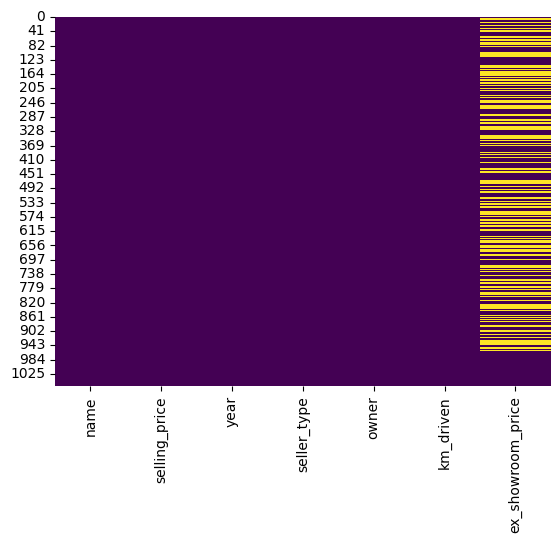

In [9]:
#Q7: Missing values trend
df.isnull().sum()
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.show()

In [10]:
 #Q8: Highest ex_showroom_price and bike name
idx = df['ex_showroom_price'].idxmax()
df.loc[idx, ['name','ex_showroom_price']]


,134
name,Harley-Davidson Street Bob
ex_showroom_price,1278000.0


In [11]:
# Q9: Total bikes listed by seller type
df['seller_type'].value_counts()

,count
seller_type,
Individual,1055
Dealer,6


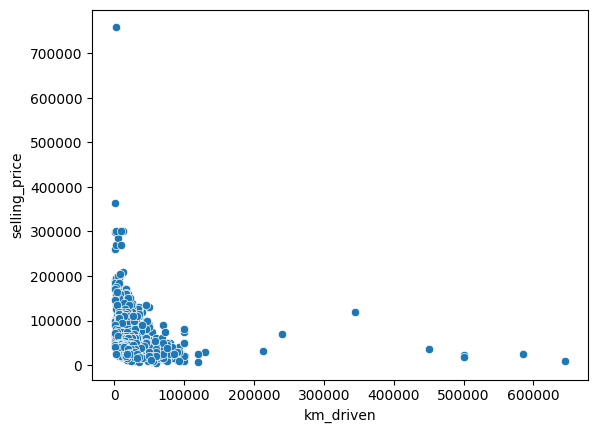

In [12]:
#Q10: Relationship between selling_price and km_driven for 1st owner
first_owner = df[df['owner']=="1st owner"]
sns.scatterplot(x="km_driven", y="selling_price", data=first_owner)
plt.show()

In [13]:
#Q11: Remove outliers in km_driven using IQR
Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

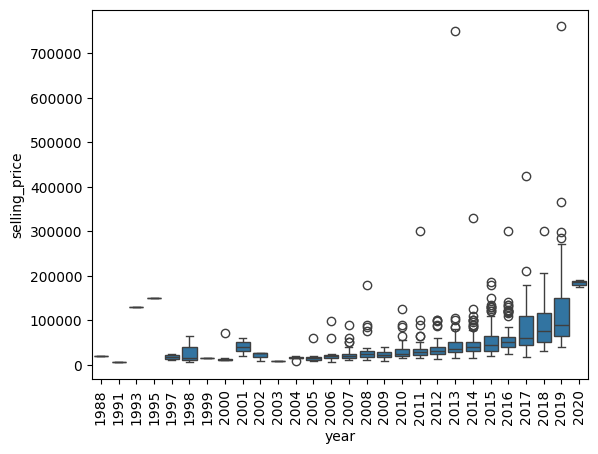

In [14]:
#Q12: Bivariate analysis (year vs selling_price)
sns.boxplot(x="year", y="selling_price", data=df)
plt.xticks(rotation=90)
plt.show()

In [15]:
#Q13: Average depreciation in selling price
import datetime
current_year = datetime.datetime.now().year
df['age'] = current_year - df['year']
df.groupby('age')['selling_price'].mean()

,selling_price
age,
5,183333.333333
6,119689.511628
7,87660.374046
8,78894.736842
9,58469.018692
10,56500.000000
11,48668.131868
12,51136.986301
13,35748.400000


In [16]:
#Q14: Bikes priced above avg price of their year
avg_price_by_year = df.groupby('year')['selling_price'].transform('mean')
df[df['selling_price'] > avg_price_by_year][['name','year','selling_price']]

,name,year,selling_price
0,Royal Enfield Classic 350,2019,175000
2,Royal Enfield Classic Gunmetal Grey,2018,150000
3,Yamaha Fazer FI V 2.0 [2016-2018],2015,65000
7,Royal Enfield Bullet 350 [2007-2011],2008,180000
13,Yamaha YZF R3,2019,365000
...,...,...,...
1004,Bajaj Pulsar NS 200,2016,60000
1005,TVS Apache RTR 160,2014,60000
1008,Bajaj Pulsar 220 F,2012,52000
1012,Bajaj Pulsar NS 200,2014,50000


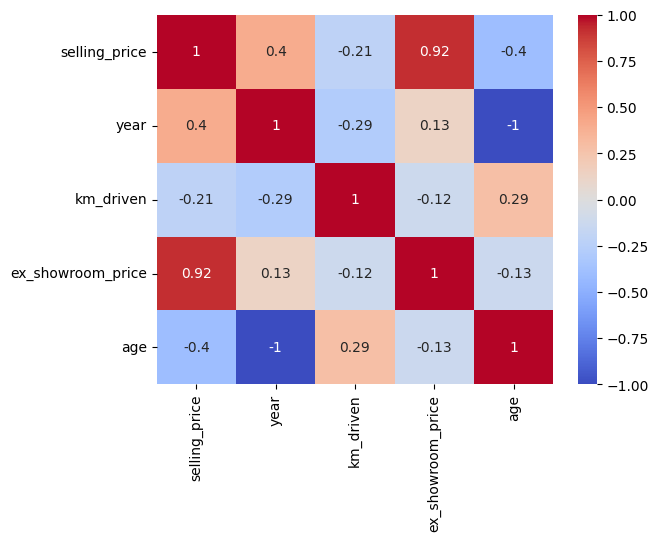

In [17]:
#Q15: Correlation heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [19]:
#second dataset
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Step 2: Upload dataset from local
from google.colab import files
uploaded = files.upload()

# Step 3: Load dataset
# For each dataset, change the filename accordingly
df = pd.read_csv("Car Sale.csv")  # Example name
df.head()


Saving Car Sale.csv to Car Sale (1).csv


,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


In [ ]:
#Q1. Average selling price of cars for each dealer
df.groupby("Dealer_Name")["Price ($)"].mean()

#Q2. Car brand with highest price variation
df.groupby("Company")["Price ($)"].std().sort_values(ascending=False).head(1)

#Q3. Distribution of prices by transmission type
sns.boxplot(x="Transmission", y="Price ($)", data=df)
plt.show()

#Q4. Distribution of prices across regions
sns.boxplot(x="Dealer_Region", y="Price ($)", data=df)
plt.show()

#Q5. Distribution of cars by body style
df["Body Style"].value_counts().plot(kind="bar")
plt.show()

#Q6. Avg selling price by gender & income
df.groupby("Gender")[["Annual Income","Price ($)"]].mean()

#Q7. Price distribution by region + count
sns.histplot(data=df, x="Price ($)", hue="Dealer_Region", kde=True)
plt.show()

#Q8. Avg car price by engine type
df.groupby("Engine")["Price ($)"].mean()

#Q9. Price variation by income bracket
pd.qcut(df["Annual Income"], 4).value_counts()
df.groupby(pd.qcut(df["Annual Income"], 4))["Price ($)"].mean()

#Q10. Top 5 most sold models
df["Model"].value_counts().head(5)

#Q11. Price vs Engine across Colors
sns.boxplot(x="Color", y="Price ($)", hue="Engine", data=df)
plt.xticks(rotation=90)
plt.show()

#Q12. Seasonal trend in sales
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df.groupby("Month")["Price ($)"].mean().plot()
plt.show()

#Q13. Price distribution by Body + Transmission
sns.boxplot(x="Body Style", y="Price ($)", hue="Transmission", data=df)
plt.xticks(rotation=90)
plt.show()

#Q14. Correlation of Price, Engine, Income
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

#Q15. Avg price by model & engine
df.groupby(["Model","Engine"])["Price ($)"].mean().head(10)


In [21]:
#third dataset
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Step 2: Upload dataset from local
from google.colab import files
uploaded = files.upload()

# Step 3: Load dataset
# For each dataset, change the filename accordingly
df = pd.read_csv("amazon.csv")  # Example name
df.head()


Saving amazon.csv to amazon.csv


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [ ]:
#Q1. Avg rating by category
df.groupby("category")["rating"].mean()

#Q2. Top products by rating_count in each category
df.groupby("category")["rating_count"].nlargest(3)

#Q3. Distribution: discounted vs actual price
sns.scatterplot(x="actual_price", y="discounted_price", data=df)
plt.show()

#Q4. Avg discount% by category
df.groupby("category")["discount_percentage"].mean()

#Q5. Most popular product names
df["product_name"].value_counts().head(10)

#Q6. Most common keywords
from collections import Counter
keywords = " ".join(df["product_name"]).split()
Counter(keywords).most_common(10)

#Q7. Most popular reviews
df["review_title"].value_counts().head(5)

#Q8. Correlation between discounted_price & rating
df[["discounted_price","rating"]].corr()

#Q9. Top 5 categories by highest ratings
df.groupby("category")["rating"].mean().sort_values(ascending=False).head(5)

#Q10. Areas for improvement
df.describe(include="all")

In [22]:
#fourth dataset
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Step 2: Upload dataset from local
from google.colab import files
uploaded = files.upload()

# Step 3: Load dataset
# For each dataset, change the filename accordingly
df = pd.read_csv("spotify.csv")  # Example name
df.head()


Saving spotify.csv to spotify.csv


,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe


In [ ]:
#Step 1: Clean null & duplicate rows
df.isnull().sum()
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

#Q1. Distribution of popularity (histogram)
sns.histplot(df["Popularity"], bins=20, kde=True)
plt.show()

#Q2. Popularity vs Duration (scatter)
sns.scatterplot(x="Duration (ms)", y="Popularity", data=df)
plt.show()

#Q3. Artist with highest number of tracks
df["Artist"].value_counts().head(10).plot(kind="bar")
plt.show()

#Q4. Top 5 least popular tracks
df.nsmallest(5, "Popularity")[["Artist","Track Name","Popularity"]]

#Q5. Avg popularity of top 5 artists
top_artists = df["Artist"].value_counts().head(5).index
df[df["Artist"].isin(top_artists)].groupby("Artist")["Popularity"].mean()

#Q6. Most popular tracks for top 5 artists
df[df["Artist"].isin(top_artists)].sort_values("Popularity", ascending=False).groupby("Artist").head(1)

#Q7. Pair plot of numerical features
sns.pairplot(df[["Popularity","Duration (ms)"]])
plt.show()

#Q8. Duration variation across artists
sns.boxplot(x="Artist", y="Duration (ms)", data=df[df["Artist"].isin(top_artists)])
plt.xticks(rotation=90)
plt.show()

#Q9. Popularity distribution across artists
sns.violinplot(x="Artist", y="Popularity", data=df[df["Artist"].isin(top_artists)])
plt.xticks(rotation=90)
plt.show()